/tmp/ipykernel_11693/3383170740.py:176: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()#pad=1.5


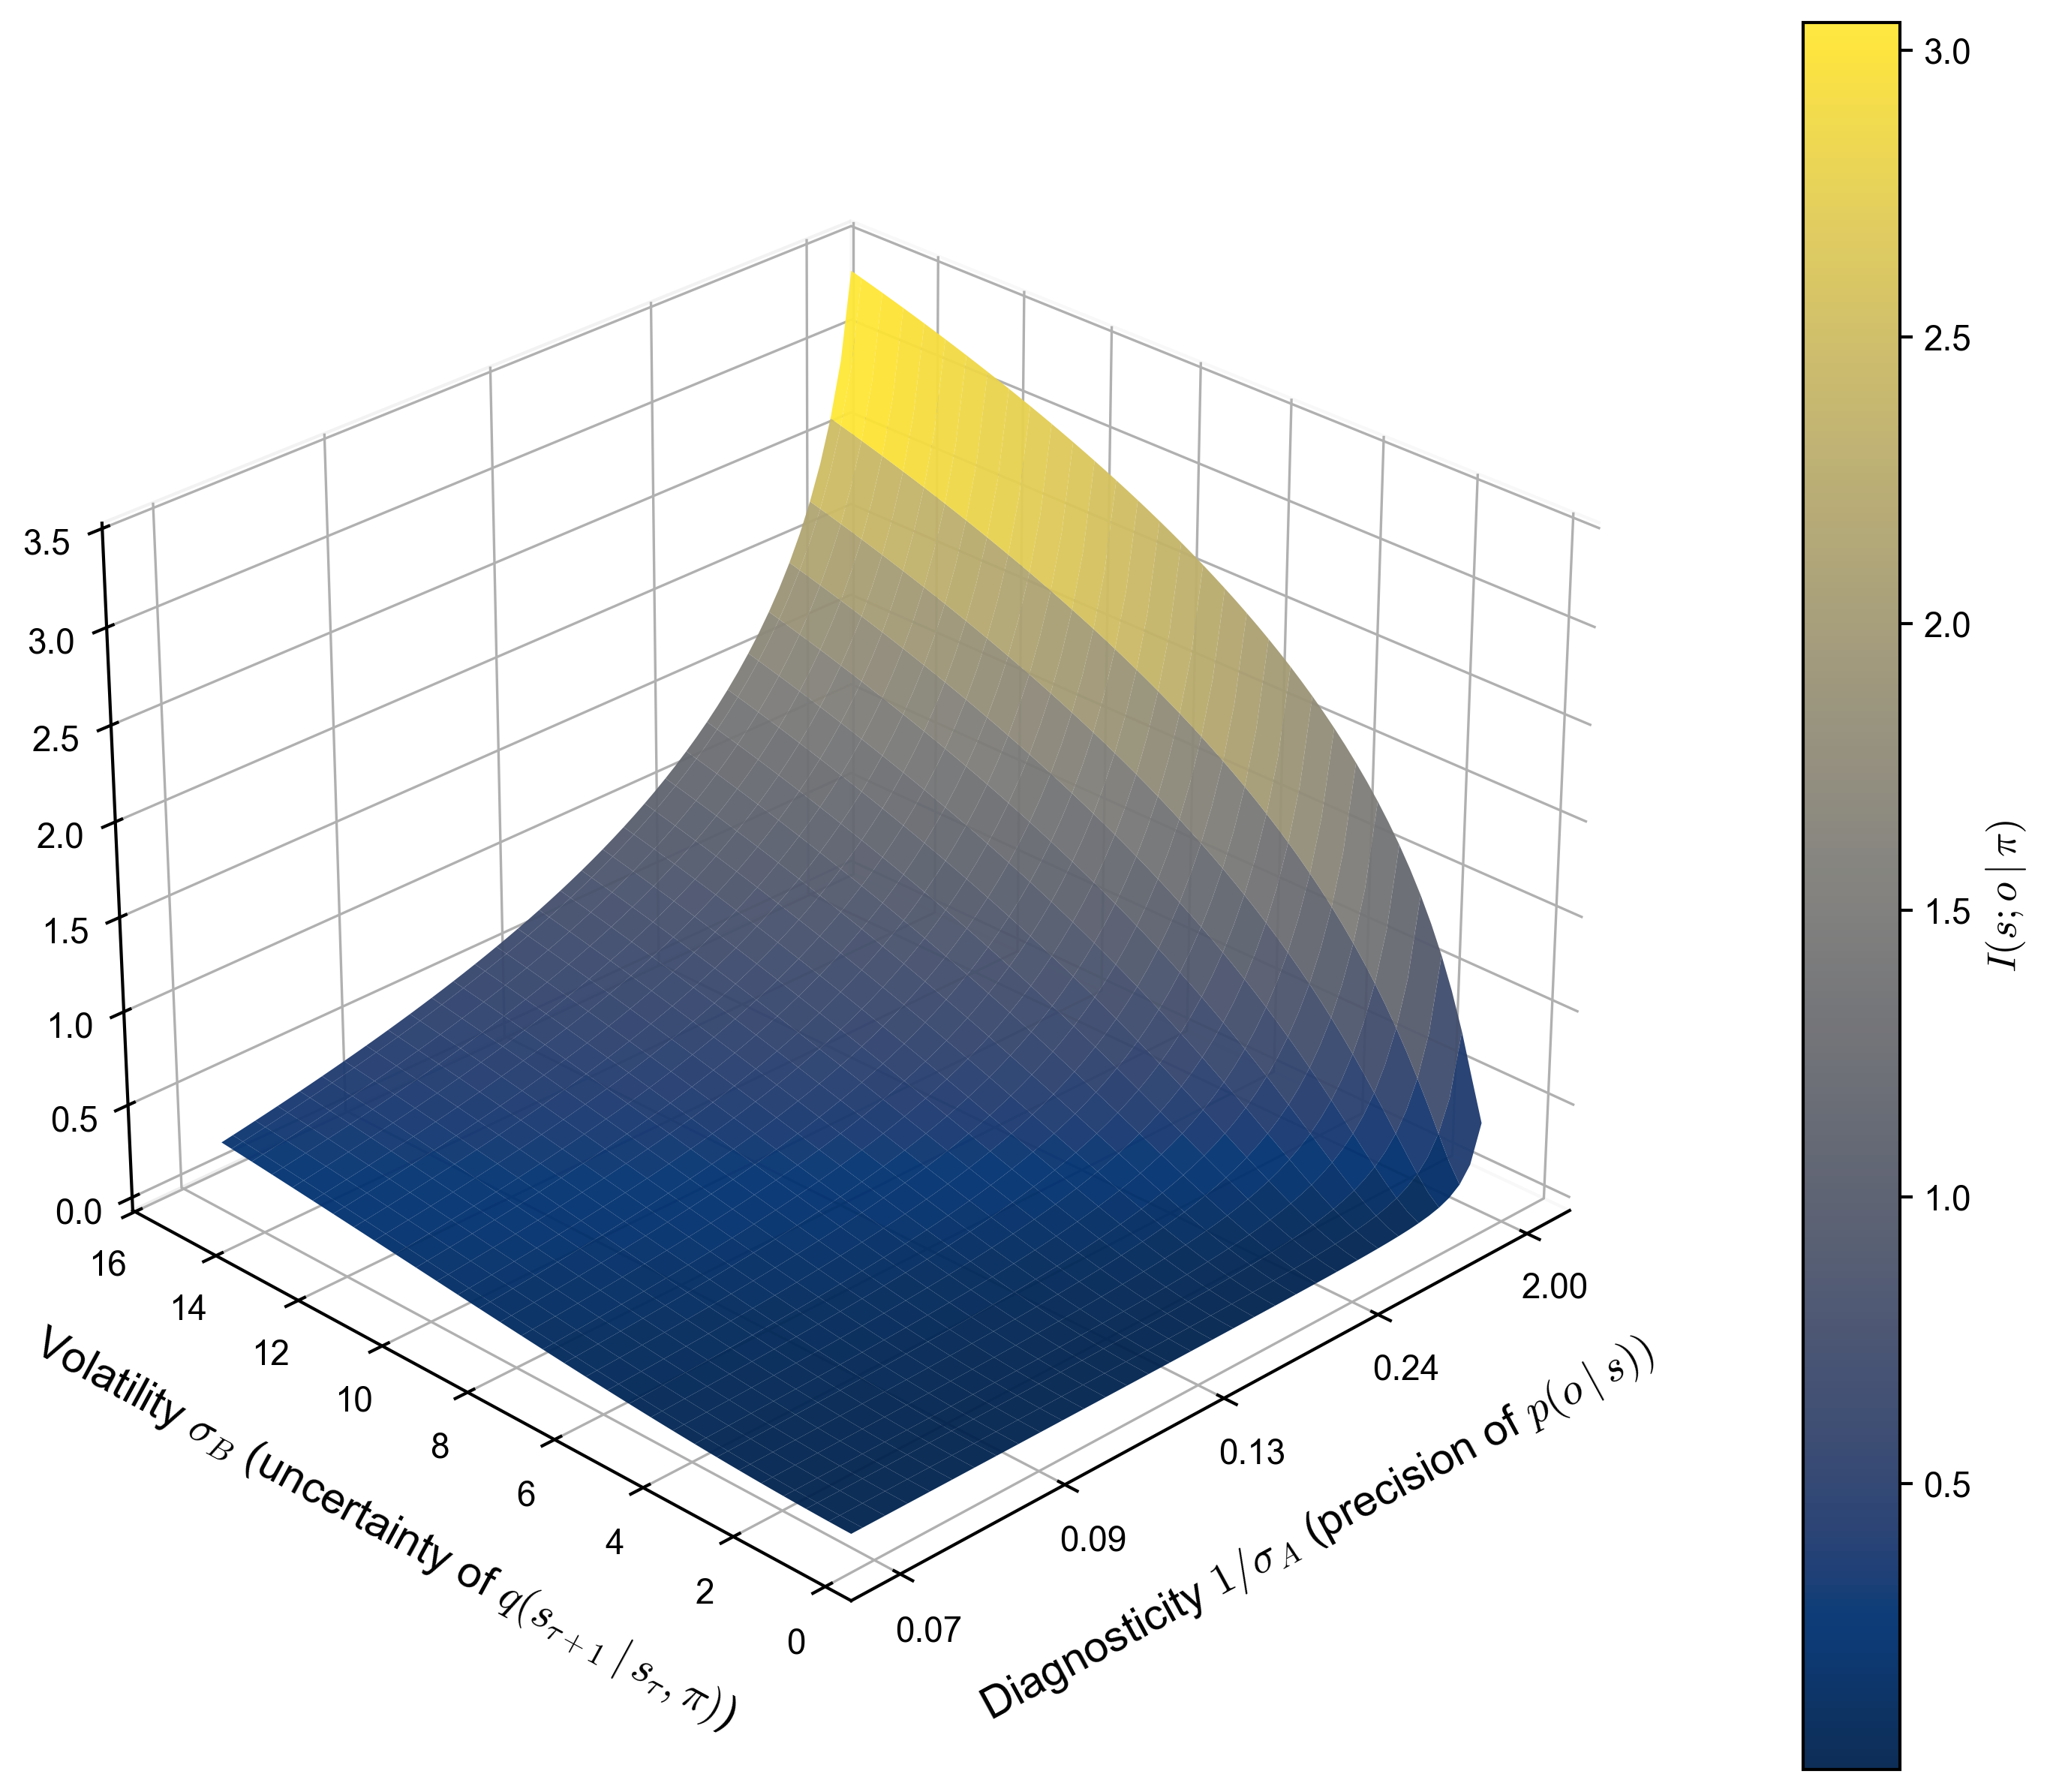

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

FONT_FAMILY = "Arial"#"Times New Roman"

LABEL_SIZE = 14
TICK_SIZE = 11
TITLE_SIZE = 15
CBAR_LABEL_SIZE = 13
CBAR_TICK_SIZE = 11

FIG_WIDTH = 12#7.5
FIG_HEIGHT = 14#6.0#6.0
DPI = 300

AXIS_LINEWIDTH = 1.0
TICK_WIDTH = 1.0
TICK_LENGTH = 4

SURFACE_ALPHA = 0.95
VIEW_ELEV = 28
VIEW_AZIM = -135

CMAP = "cividis"

rcParams["font.family"] = FONT_FAMILY
rcParams["font.size"] = 12
rcParams["axes.linewidth"] = AXIS_LINEWIDTH
rcParams["xtick.major.width"] = TICK_WIDTH
rcParams["ytick.major.width"] = TICK_WIDTH
rcParams["xtick.major.size"] = TICK_LENGTH
rcParams["ytick.major.size"] = TICK_LENGTH
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42

rcParams["mathtext.fontset"] = "cm"


epsilon = 1e-12
s_dim = 100
o_dim = 100
qs_mean = 50.5  


qs_std_values = np.linspace(0.5, 15.0, 60)
A_std_values = np.linspace(0.5, 15.0, 60)


def wrapped_norm_pdf(x, mean, std, wrap_size):

    pdf = np.zeros_like(x, dtype=np.float64)
    for k in [-1, 0, 1]:
        pdf += np.exp(-0.5 * ((x - mean + k * wrap_size) / std) ** 2) / (std * np.sqrt(2 * np.pi))
    return pdf

def make_likelihood_matrix(s_dim, o_dim, A_std, eps=1e-12):
    obs = np.arange(o_dim)
    A = np.zeros((o_dim, s_dim), dtype=np.float64)

    for s in range(s_dim):
        A[:, s] = wrapped_norm_pdf(obs, mean=s, std=A_std, wrap_size=o_dim) + eps

    A /= (A.sum(axis=0, keepdims=True) + eps)
    return A

def make_qs(s_dim, mean, qs_std, eps=1e-12):

    states = np.arange(s_dim)
    qs = wrapped_norm_pdf(states, mean=mean, std=qs_std, wrap_size=s_dim) + eps
    qs /= (qs.sum() + eps)
    return qs

def compute_pbs(A, qs, eps=1e-12):
    """
    pBS = H[q(o)] - E_q(s)[ H[p(o|s)] ]
    """
    qo = A @ qs
    qo /= (qo.sum() + eps)

    entropy_qo = -np.sum(qo * np.log(qo + eps))
    H_A_per_s = -np.sum(A * np.log(A + eps), axis=0)
    ambiguity = np.sum(H_A_per_s * qs)

    pbs = entropy_qo - ambiguity
    return pbs

pbs_matrix = np.zeros((len(qs_std_values), len(A_std_values)))

for i, qs_std in enumerate(qs_std_values):
    qs = make_qs(s_dim=s_dim, mean=qs_mean, qs_std=qs_std, eps=epsilon)

    for j, A_std in enumerate(A_std_values):
        A = make_likelihood_matrix(s_dim=s_dim, o_dim=o_dim, A_std=A_std, eps=epsilon)
        pbs_matrix[i, j] = compute_pbs(A, qs, eps=epsilon)


X_A_std, Y_qs_std = np.meshgrid(A_std_values, qs_std_values)

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X_A_std,
    Y_qs_std,
    pbs_matrix,
    cmap=CMAP,
    linewidth=0,
    antialiased=True,
    alpha=SURFACE_ALPHA
)
ax.invert_xaxis()

xticks = np.linspace(A_std_values.min(), A_std_values.max(), 5)

xtick_labels = [f"{1/x:.2f}" for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

ax.set_xlabel(r"Diagnosticity $1/\sigma_{A}$ (precision of $p(o\mid s))$", fontsize=LABEL_SIZE, labelpad=12)

ax.set_ylabel(r"Volatility $\sigma_{B}$ (uncertainty of $q(s_{\tau + 1}\mid s_{\tau}, \pi)$)", fontsize=LABEL_SIZE, labelpad=12)
ax.set_zlabel(r"$I(s;o\mid \pi)$", fontsize=LABEL_SIZE, labelpad=10)




ax.tick_params(axis="x", labelsize=TICK_SIZE, pad=2)
ax.tick_params(axis="y", labelsize=TICK_SIZE, pad=2)
ax.tick_params(axis="z", labelsize=TICK_SIZE, pad=2)


ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False


ax.grid(True)


cbar = fig.colorbar(surf, ax=ax, shrink=0.72, aspect=18, pad=0.08)
cbar.set_label(r"$I(s;o\mid \pi)$", fontsize=CBAR_LABEL_SIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)



plt.tight_layout()#pad=1.5
plt.show()

fig.savefig("Iso_3D_surface.pdf", bbox_inches="tight")
fig.savefig("Iso_3D_surface.png", bbox_inches="tight", dpi=600)